# Quality-Adjusted Singapore HDB Resale Market Analysis

## Decision question

How much of the observed resale-price movement remains after controlling for the recorded mix of flats sold?

This report is designed for buyers and market analysts. It combines a chronological model evaluation, a hedonic price index, the official HDB Resale Price Index benchmark, distribution analysis and robustness checks. Results describe recorded transactions; they are not causal estimates or property valuations.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path("..").resolve()
REPORTS = PROJECT_ROOT / "reports"
IMAGES = PROJECT_ROOT / "images"
DATA = PROJECT_ROOT / "data" / "processed"

PRIMARY = "#0B3C5D"
ACCENT = "#E07A5F"
plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.2f}".format

## Reproducible data snapshot

In [2]:
snapshot = json.loads((DATA / "snapshot_metadata.json").read_text(encoding="utf-8"))
parquet_path = DATA / "hdb_resale_clean.parquet"
transactions = pd.read_parquet(parquet_path)

def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as input_file:
        for chunk in iter(lambda: input_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

assert len(transactions) == snapshot["row_count"]
assert len(transactions.columns) == snapshot["column_count"]
assert sha256(parquet_path) == snapshot["processed_parquet_sha256"]

advanced_metadata = json.loads(
    (REPORTS / "advanced_analysis_metadata.json").read_text(encoding="utf-8")
)
assert advanced_metadata["transaction_source"]["sha256"] == snapshot["processed_sha256"]
assert advanced_metadata["transaction_source"]["row_count"] == snapshot["row_count"]

pd.Series({
    "Coverage": f"{snapshot['month_min']} to {snapshot['month_max']}",
    "Rows": f"{snapshot['row_count']:,}",
    "Columns": snapshot["column_count"],
    "Exact duplicate rows retained": f"{snapshot['fully_identical_rows_retained']:,}",
    "Parquet SHA-256": snapshot["processed_parquet_sha256"],
}, name="Snapshot")

Coverage                                                        2017-01 to 2026-09
Rows                                                                       239,977
Columns                                                                         17
Exact duplicate rows retained                                                  318
Parquet SHA-256                  dc1a9a47f28f8b5cb90e0f7f8cc702e14f1e1f9f9135ea...
Name: Snapshot, dtype: object

## 1. Raw versus quality-adjusted movement

The model controls for floor area, remaining lease, storey, town, flat type and flat model. Month fixed effects form the quality-adjusted index. This separates recorded transaction mix from the common time component in the model; it does not establish causal appreciation.


From **2017-01** through **2026-08**, the raw monthly median index increased **56.8%**. The quality-adjusted model increased **56.6%**. The raw-versus-adjusted difference is **0.2 percentage points** under this model; it is not a causal attribution. The incomplete **2026-09** source month (512 records) is excluded from the model and index.


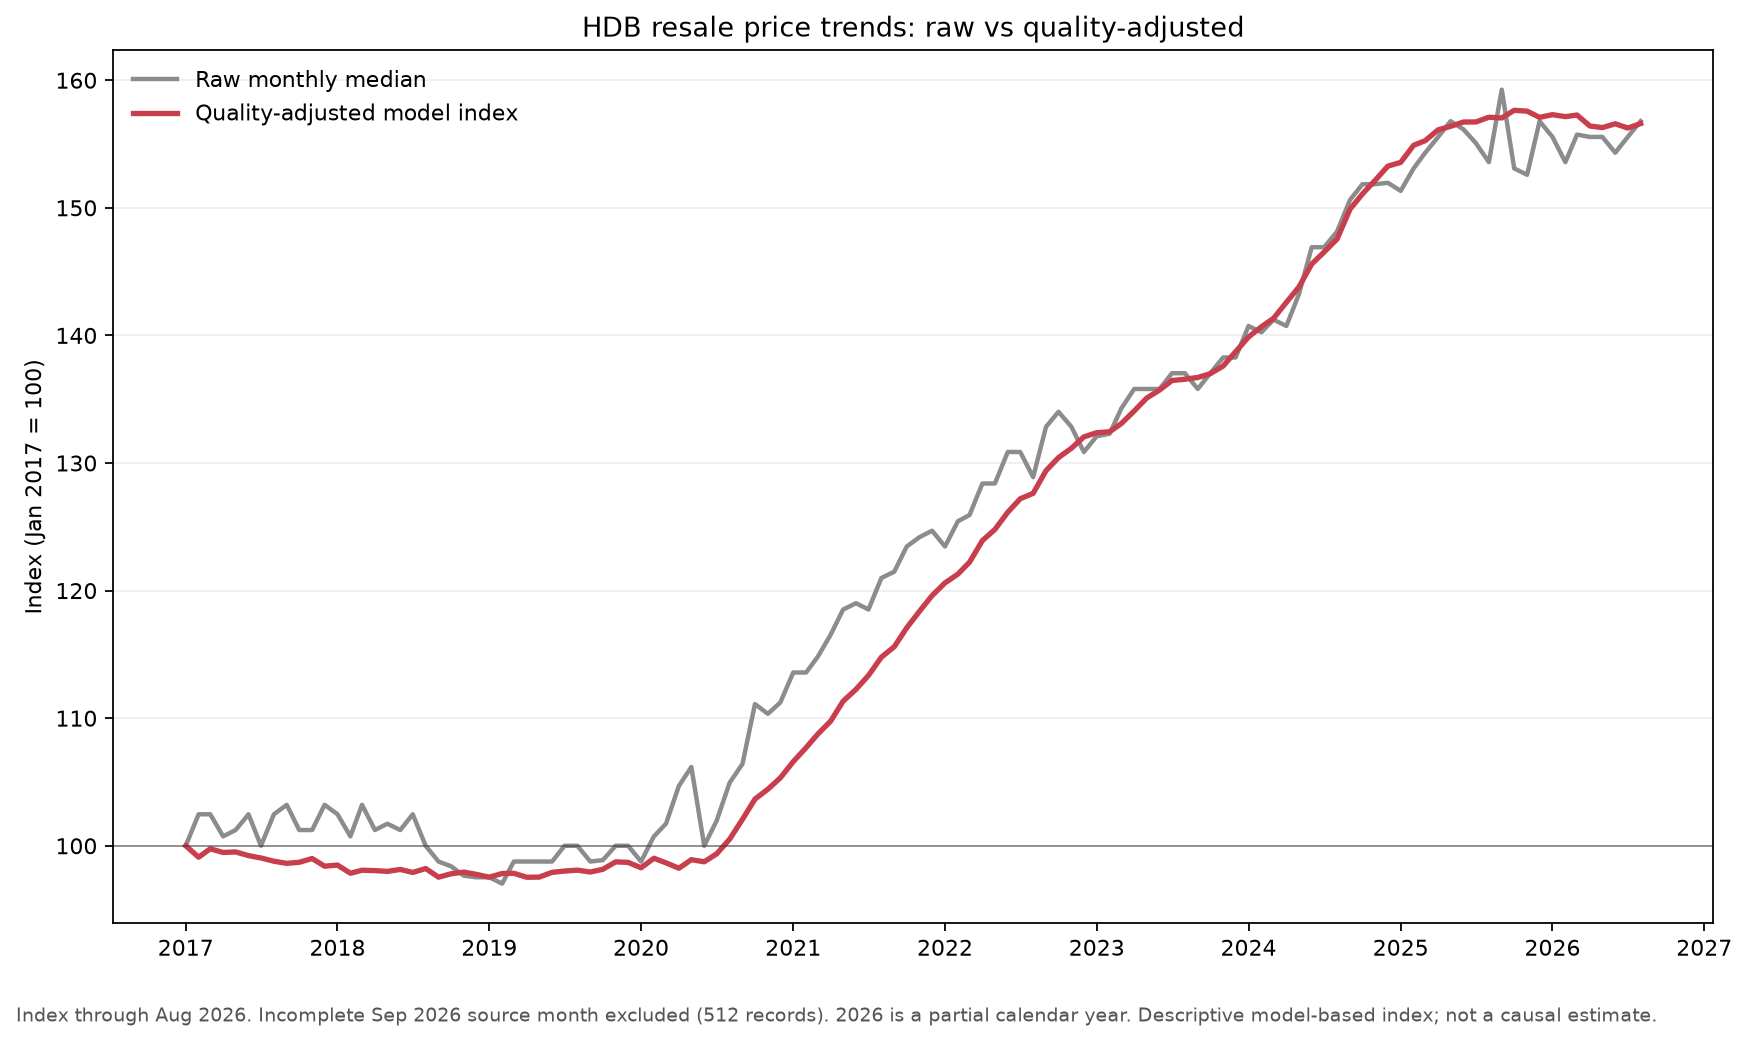

In [3]:
model_report = json.loads(
    (REPORTS / "price_model_metrics.json").read_text(encoding="utf-8")
)
assert model_report["input_provenance"]["sha256"] == snapshot["processed_parquet_sha256"]
assert sha256(REPORTS / "quality_adjusted_price_index.csv") == model_report["output_sha256"]["quality_adjusted_index"]
index_summary = model_report["index_summary"]
provenance = model_report["input_provenance"]
coverage_note = ""
if provenance["provisional_latest_month_excluded"]:
    coverage_note = (
        f" The incomplete **{provenance['excluded_month']}** source month "
        f"({provenance['excluded_rows']:,} records) is excluded from the model and index."
    )

display(Markdown(f'''
From **{index_summary['base_month']}** through **{index_summary['latest_month']}**, the raw monthly median index increased **{index_summary['raw_change_from_base_pct']:.1f}%**. The quality-adjusted model increased **{index_summary['quality_adjusted_change_from_base_pct']:.1f}%**. The raw-versus-adjusted difference is **{index_summary['raw_minus_adjusted_change_percentage_points']:.1f} percentage points** under this model; it is not a causal attribution.{coverage_note}
'''))
display(Image(filename=str(IMAGES / "raw_vs_quality_adjusted_price_index.png")))

## 2. Chronological holdout evaluation

In [4]:
split = model_report["split"]
metrics = (
    pd.DataFrame(model_report["holdout_metrics"])
      .T.rename_axis("Model")
      .rename(columns={"mae": "MAE (S$)", "rmse": "RMSE (S$)", "r2": "R²"})
)
display(Markdown(
    f"Training ends **{split['training_end_month']}**. The untouched holdout covers "
    f"**{split['holdout_start_month']} to {split['holdout_end_month']}** "
    f"({split['holdout_rows']:,} records)."
))
display(metrics.style.format({"MAE (S$)": "S${:,.0f}", "RMSE (S$)": "S${:,.0f}", "R²": "{:.3f}"}))

Training ends **2025-08**. The untouched holdout covers **2025-09 to 2026-08** (24,592 records).

,MAE (S$),R²,RMSE (S$)
Model,,,
hedonic_ridge,"S$52,844",0.893,"S$69,635"
training_median_baseline,"S$206,276",-0.654,"S$274,221"


In [5]:
importance = pd.read_csv(REPORTS / "price_model_permutation_importance.csv")
importance_display = importance[[
    "feature_group", "mae_increase", "mae_increase_std", "r2_decrease"
]].copy()
importance_display.columns = [
    "Feature group", "MAE increase (S$)", "MAE increase SD", "R² decrease"
]
importance_display.style.format({
    "MAE increase (S$)": "S${:,.0f}",
    "MAE increase SD": "S${:,.0f}",
    "R² decrease": "{:.3f}",
})

,Feature group,MAE increase (S$),MAE increase SD,R² decrease
0,floor_area,"S$109,544",S$249,0.849
1,remaining_lease,"S$79,135",S$467,0.519
2,town,"S$78,458",S$612,0.590
3,storey,"S$10,344",S$103,0.052
4,flat_model,"S$7,563",S$34,0.038
5,flat_type,"S$1,243",S$62,0.006
6,transaction_month,S$-341,S$146,-0.000


Permutation importance is computed only after evaluating the model on the holdout. Negative values mean shuffling that group did not worsen the selected metric, often because predictors overlap; they are not evidence of a protective or causal effect.

## 3. Benchmark against the official HDB Resale Price Index

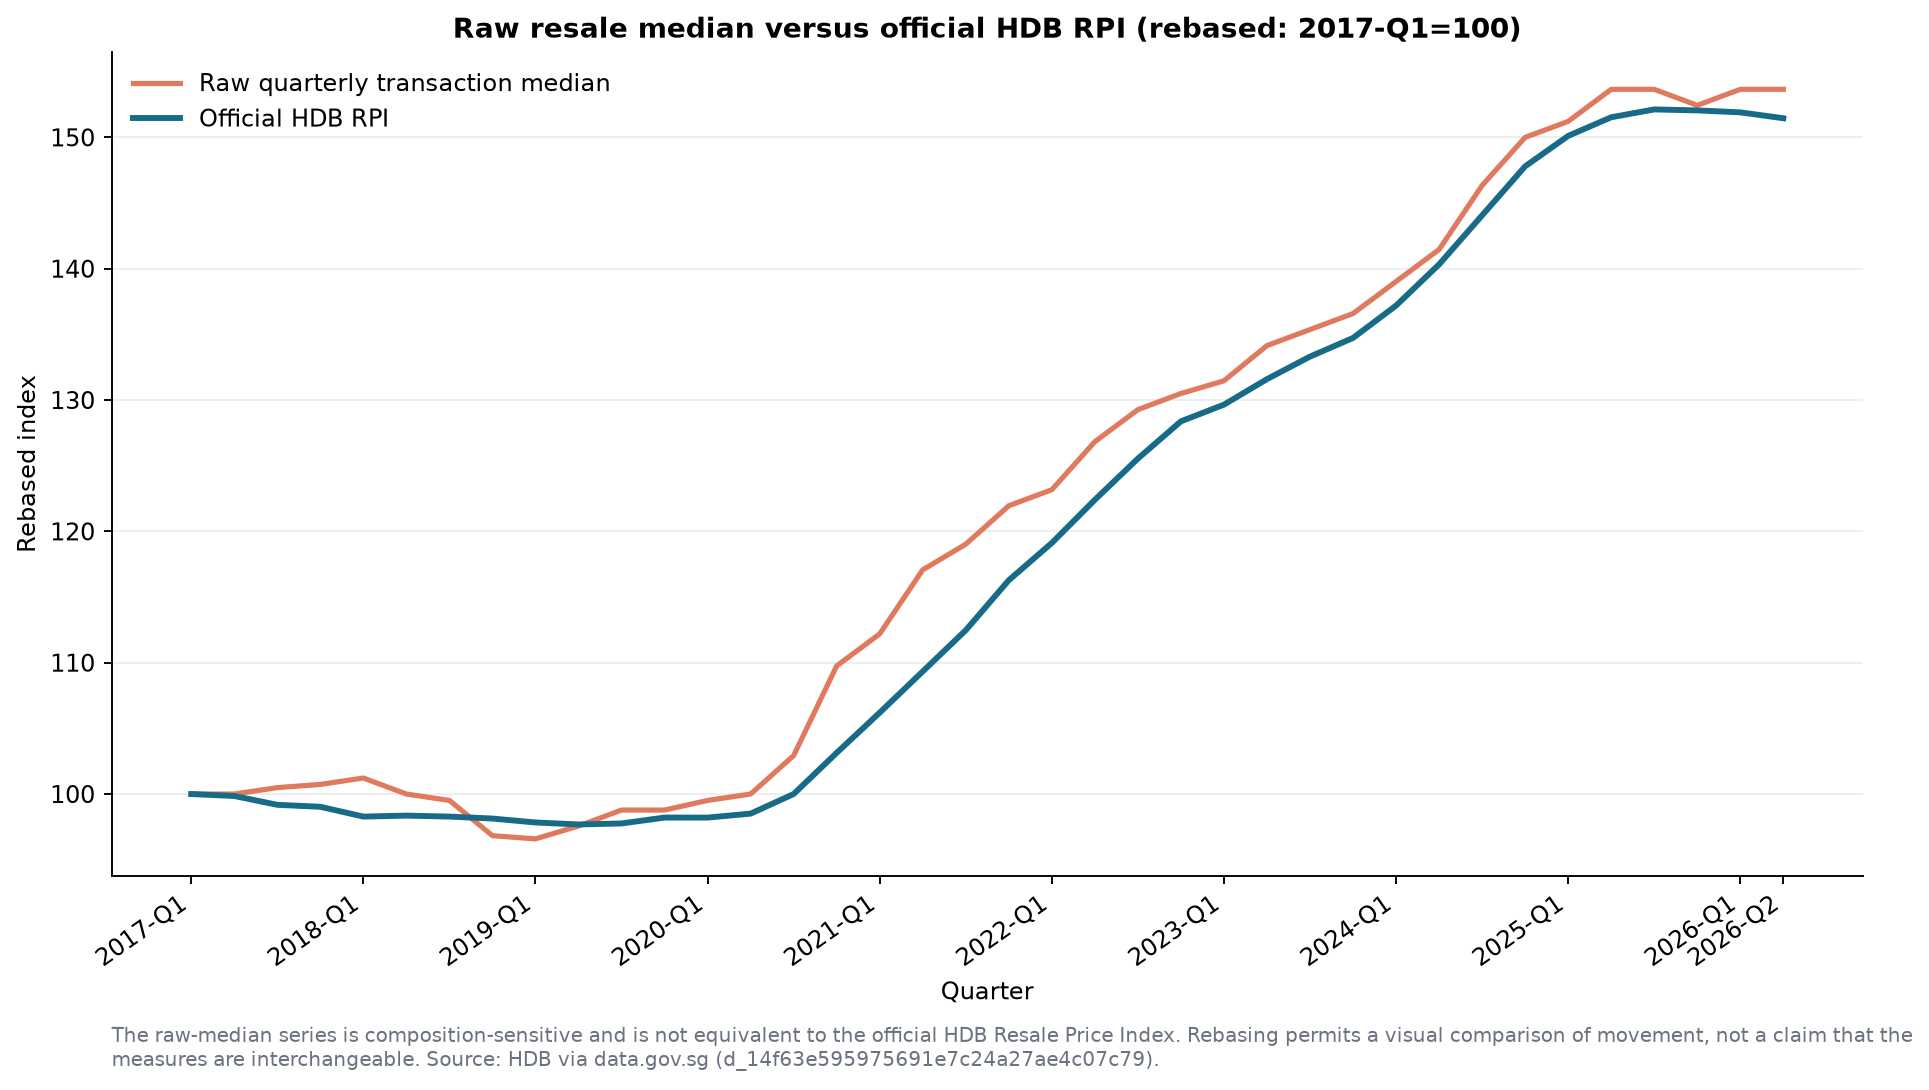

,quarter,transaction_count,months_observed,raw_median_resale_price,has_all_three_month_labels,official_rpi,raw_median_rebased,official_rpi_rebased,rebased_gap_points,raw_median_qoq_pct,official_rpi_qoq_pct,base_quarter
30,2024-Q3,7831,3,"600,000.00",True,192.90,146.34,144.06,2.28,3.45,2.66,2017-Q1
31,2024-Q4,6180,3,"615,000.00",True,197.90,150.00,147.80,2.20,2.50,2.59,2017-Q1
32,2025-Q1,6303,3,"620,000.00",True,201.00,151.22,150.11,1.11,0.81,1.57,2017-Q1
33,2025-Q2,6823,3,"630,000.00",True,202.90,153.66,151.53,2.13,1.61,0.95,2017-Q1
34,2025-Q3,6939,3,"630,000.00",True,203.70,153.66,152.13,1.53,0.00,0.39,2017-Q1
35,2025-Q4,5020,3,"625,000.00",True,203.60,152.44,152.05,0.39,-0.79,-0.05,2017-Q1
36,2026-Q1,6042,3,"630,000.00",True,203.40,153.66,151.90,1.75,0.80,-0.10,2017-Q1
37,2026-Q2,6185,3,"630,000.00",True,202.80,153.66,151.46,2.20,0.00,-0.29,2017-Q1


In [6]:
rpi_benchmark = pd.read_csv(REPORTS / "quarterly_rpi_benchmark.csv")
display(Image(filename=str(IMAGES / "raw_median_vs_official_rpi.png")))
rpi_benchmark.tail(8)

The official RPI and raw transaction median are rebased to the first overlapping quarter for visual comparison. They are not interchangeable: the raw median changes with the types and locations of flats transacted, while the official index uses its own quality-adjustment methodology.

## 4. Price distribution, not only the median

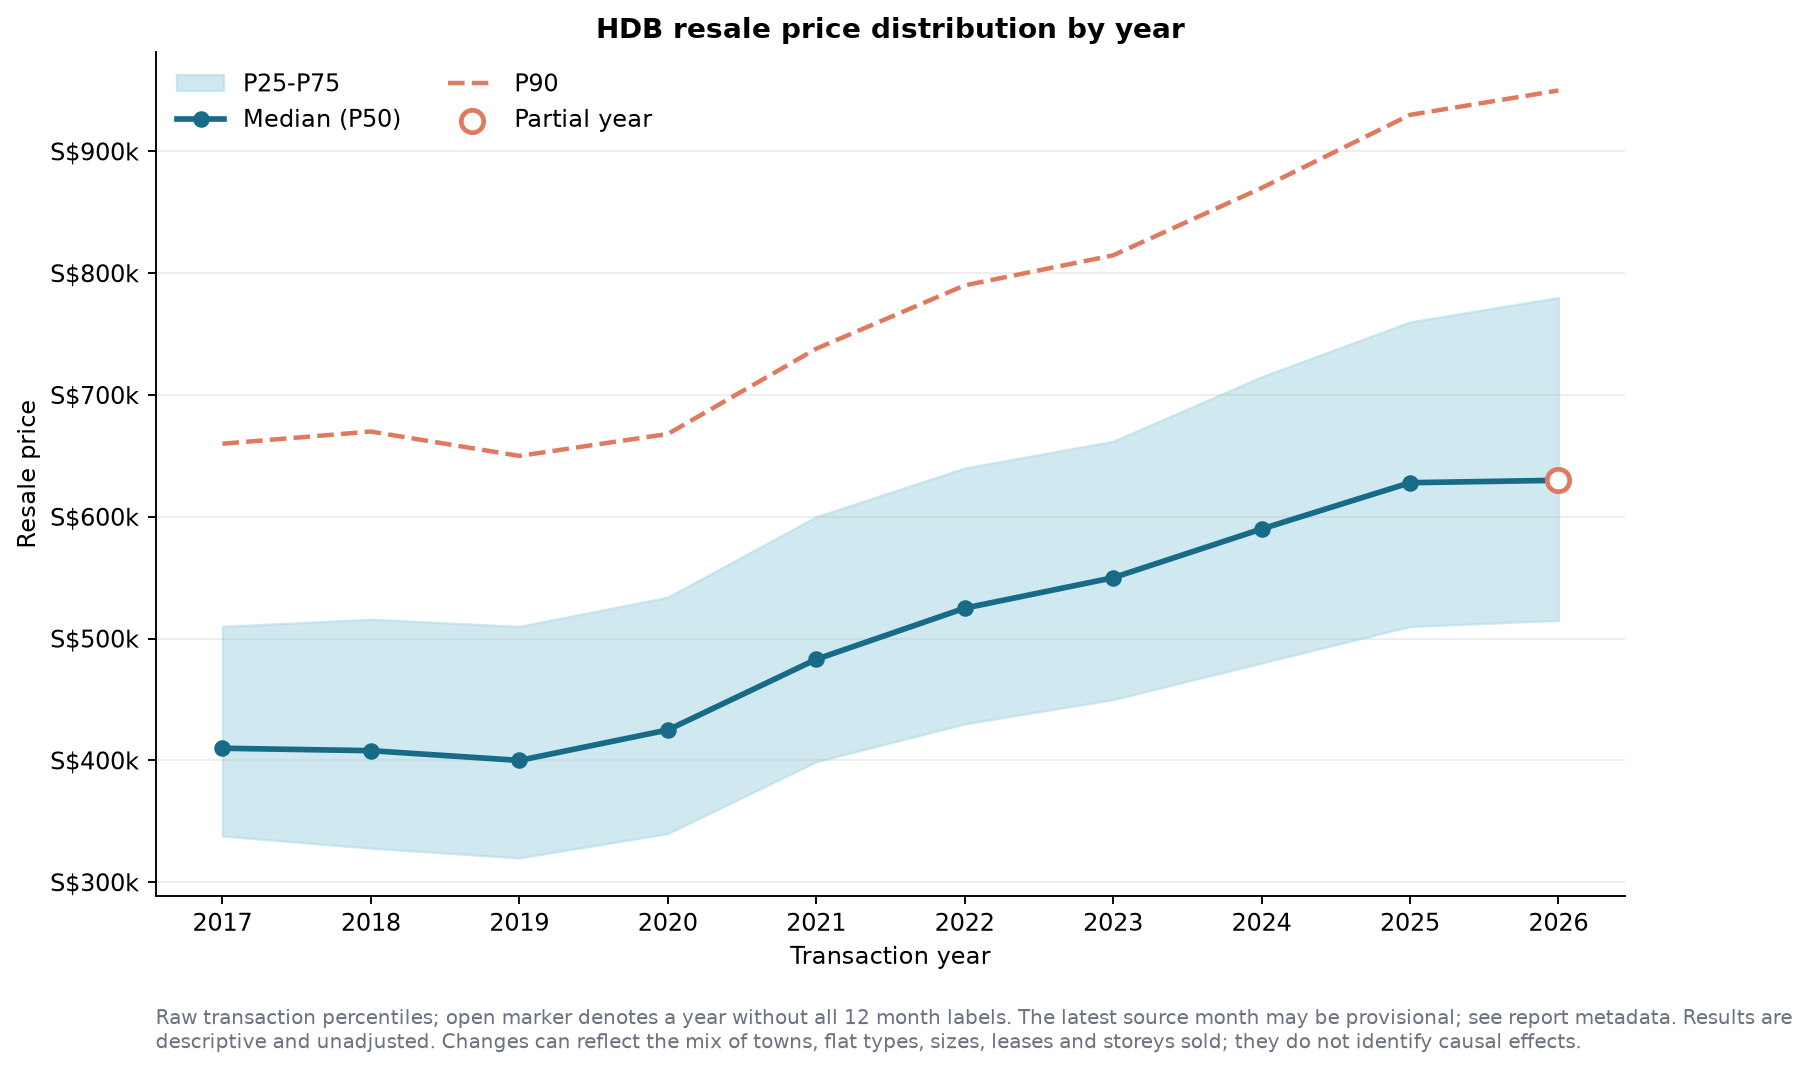

,year,transaction_count,months_observed,is_complete_year,first_month,latest_month,p25,p50,p75,p90
5,2022,"26,720",12,True,2022-01,2022-12,"S$430,000","S$525,000","S$640,000","S$790,000"
6,2023,"25,754",12,True,2023-01,2023-12,"S$450,000","S$550,000","S$662,000","S$814,666"
7,2024,"27,832",12,True,2024-01,2024-12,"S$480,000","S$590,000","S$715,000","S$870,000"
8,2025,"25,085",12,True,2025-01,2025-12,"S$510,000","S$628,000","S$760,000","S$930,000"
9,2026,"17,910",9,False,2026-01,2026-09,"S$515,000","S$630,000","S$780,000","S$950,000"


In [7]:
annual_distribution = pd.read_csv(REPORTS / "annual_price_quantiles.csv")
display(Image(filename=str(IMAGES / "annual_price_distribution.png")))
annual_distribution.tail().style.format({
    "p25": "S${:,.0f}",
    "p50": "S${:,.0f}",
    "p75": "S${:,.0f}",
    "p90": "S${:,.0f}",
    "transaction_count": "{:,.0f}",
})

## 5. Million-dollar transaction share

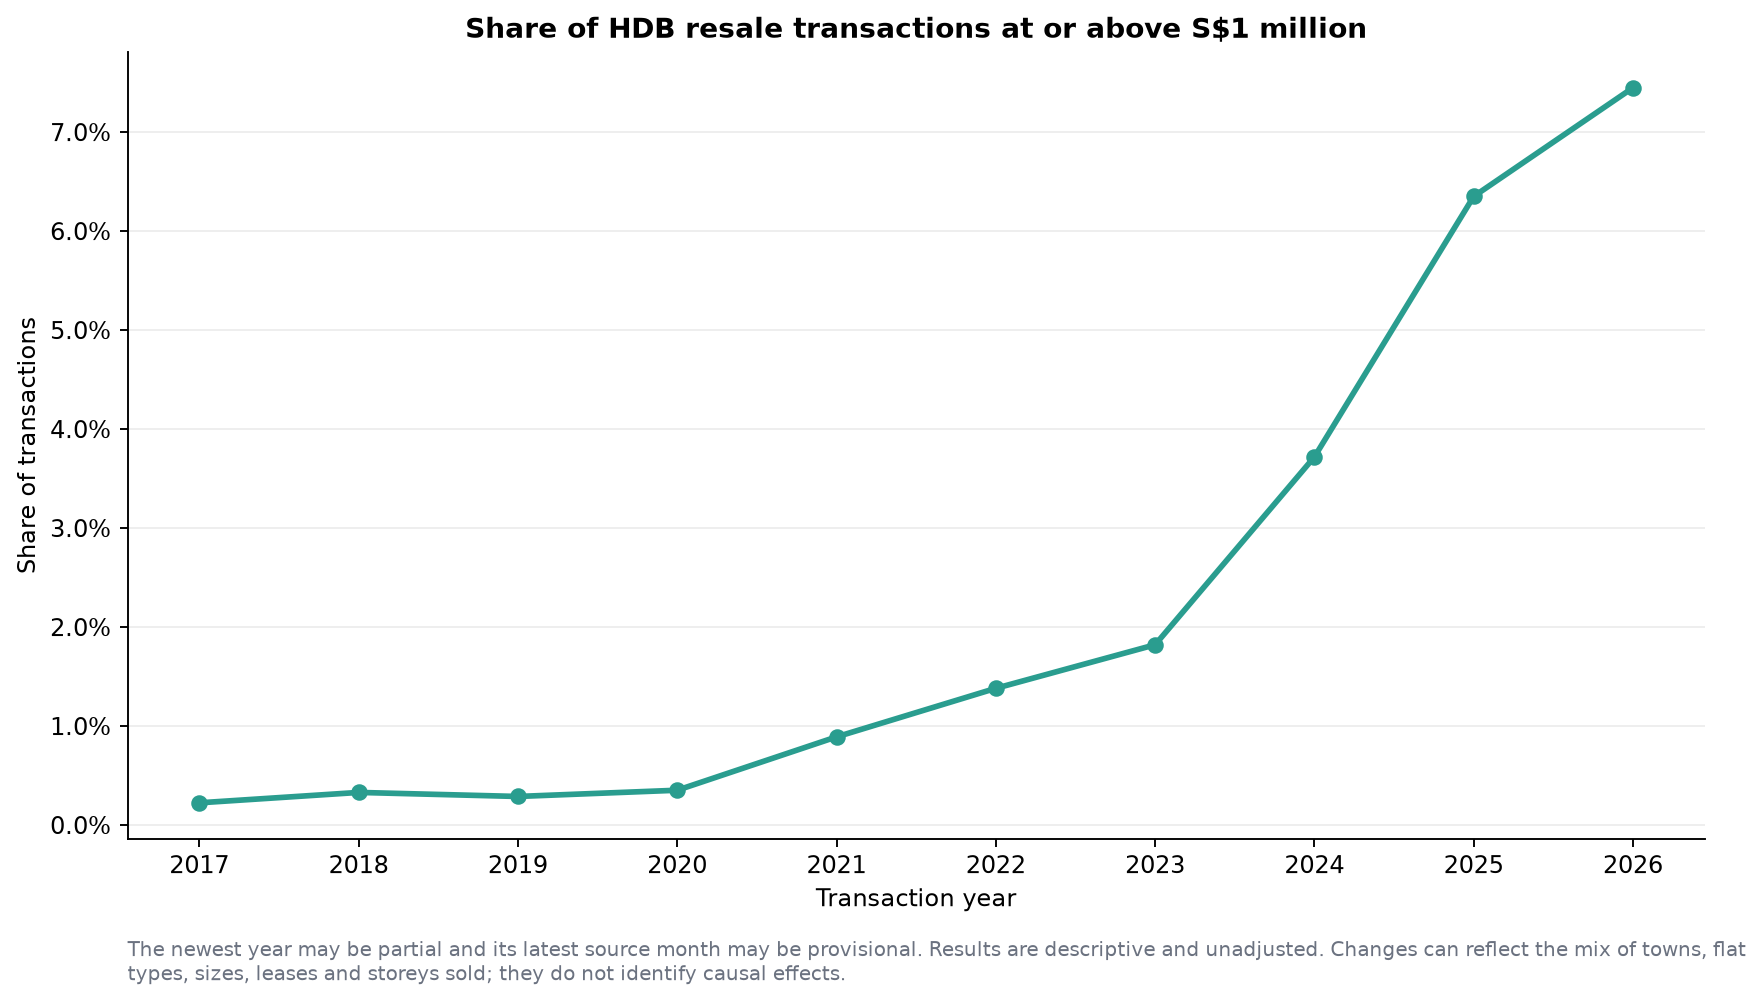

,year,transaction_count,million_dollar_transactions,million_dollar_share_pct,threshold_sgd
5,2022,"26,720",369,1.38%,1000000.000000
6,2023,"25,754",469,1.82%,1000000.000000
7,2024,"27,832","1,035",3.72%,1000000.000000
8,2025,"25,085","1,593",6.35%,1000000.000000
9,2026,"17,910","1,334",7.45%,1000000.000000


In [8]:
million_share = pd.read_csv(REPORTS / "million_dollar_share_by_year.csv")
display(Image(filename=str(IMAGES / "million_dollar_share_by_year.png")))
million_share.tail().style.format({
    "transaction_count": "{:,.0f}",
    "million_dollar_transactions": "{:,.0f}",
    "million_dollar_share_pct": "{:.2f}%",
})

## 6. Remaining lease and observed price

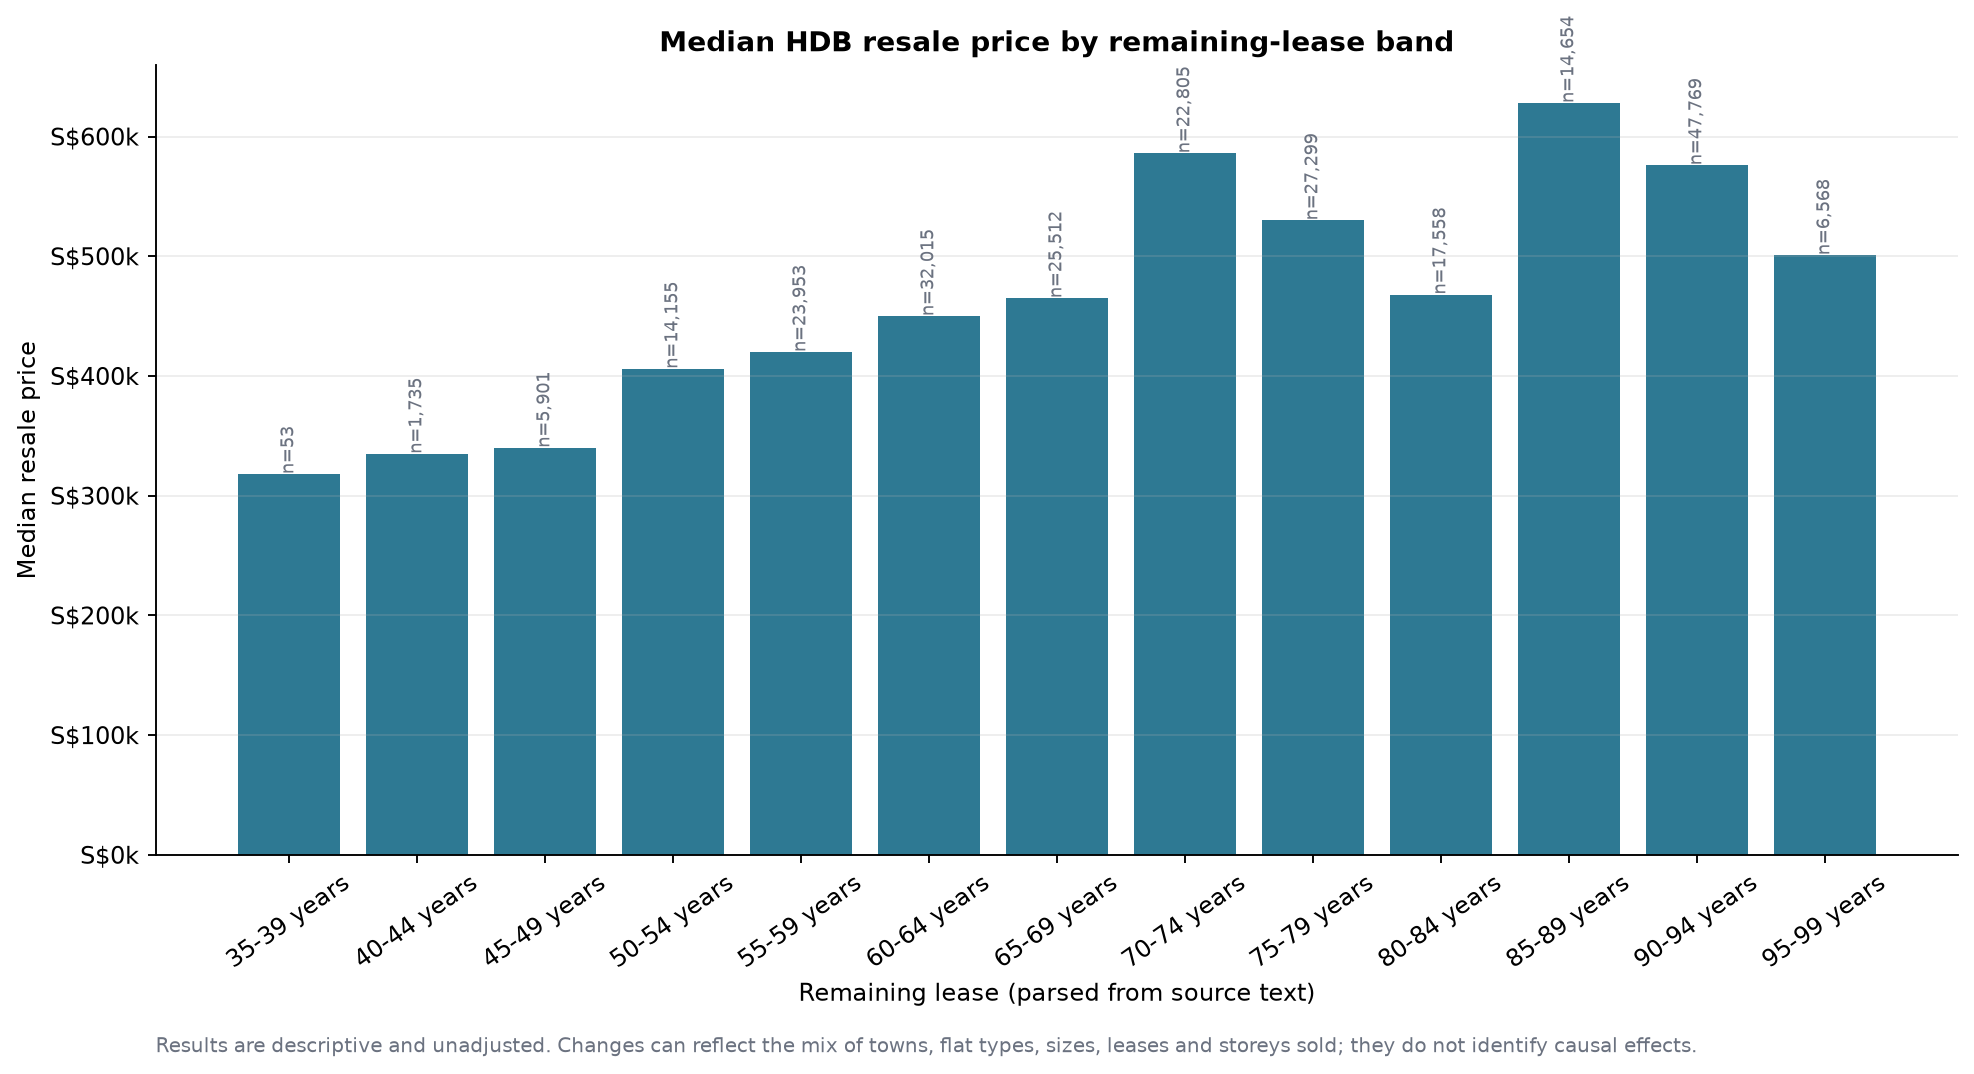

,remaining_lease_band,lease_bin_start_years,lease_bin_end_years,transaction_count,p25,median_resale_price,p75
0,35-39 years,35,39,53,"S$310,000","S$318,000","S$340,000"
1,40-44 years,40,44,"1,735","S$305,000","S$335,000","S$365,000"
2,45-49 years,45,49,"5,901","S$280,000","S$340,000","S$420,000"
3,50-54 years,50,54,"14,155","S$333,000","S$406,000","S$500,000"
4,55-59 years,55,59,"23,953","S$340,000","S$420,000","S$533,000"
5,60-64 years,60,64,"32,015","S$360,000","S$450,000","S$580,000"
6,65-69 years,65,69,"25,512","S$342,000","S$465,000","S$638,000"
7,70-74 years,70,74,"22,805","S$498,000","S$586,000","S$698,888"
8,75-79 years,75,79,"27,299","S$436,000","S$530,000","S$625,000"
9,80-84 years,80,84,"17,558","S$396,000","S$468,000","S$595,000"


In [9]:
lease_bands = pd.read_csv(REPORTS / "remaining_lease_bands.csv")
display(Image(filename=str(IMAGES / "remaining_lease_price_bands.png")))
lease_bands.style.format({
    "transaction_count": "{:,.0f}",
    "p25": "S${:,.0f}",
    "median_resale_price": "S${:,.0f}",
    "p75": "S${:,.0f}",
})

Lease-band medians remain descriptive. Location, construction cohort and flat characteristics differ across bands. The hedonic model includes a nonlinear remaining-lease term, but its association should still not be interpreted as a standalone causal discount.

## 7. Town comparison with endpoint sample guards

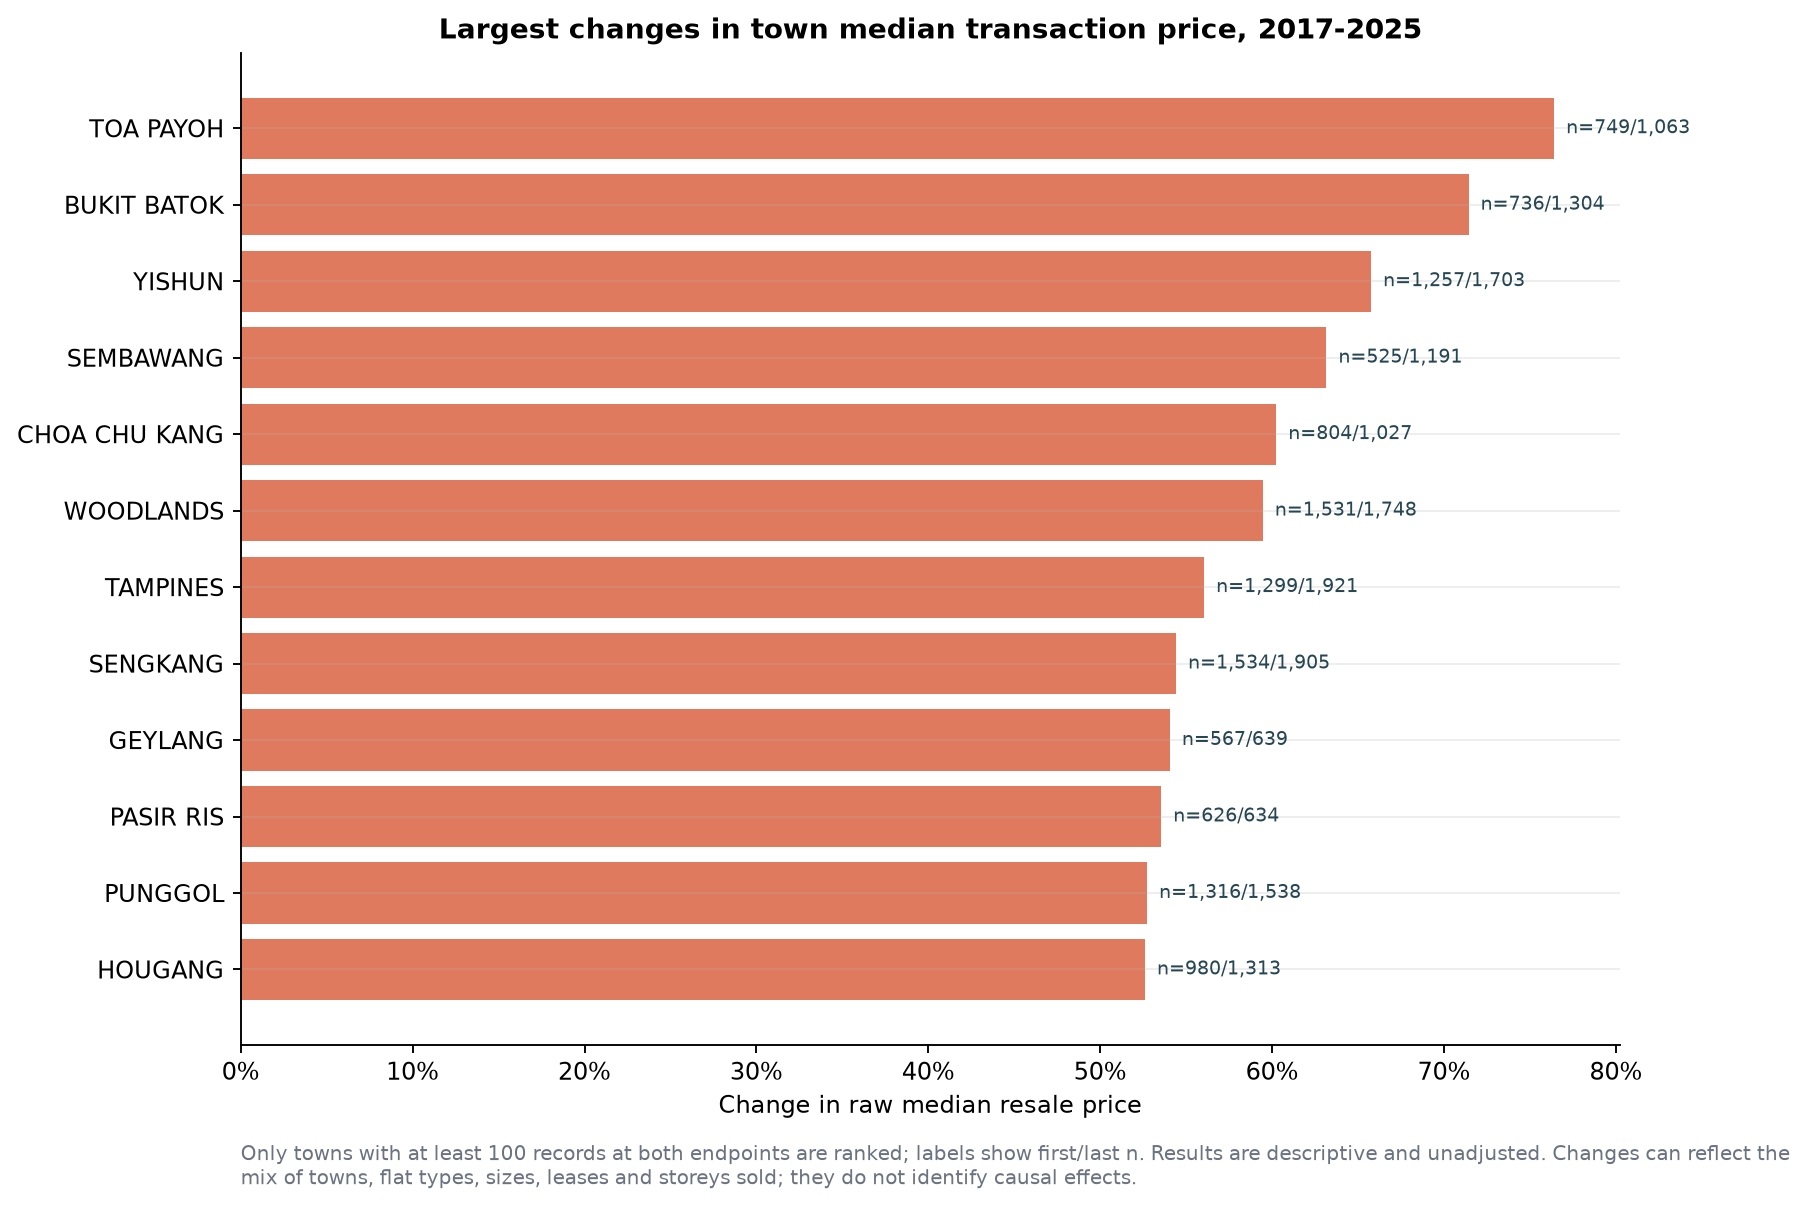

,town,first_year,last_year,first_year_count,last_year_count,median_price_growth_pct
0,TOA PAYOH,2017,2025,749,"1,063",76.4%
1,BUKIT BATOK,2017,2025,736,"1,304",71.4%
2,YISHUN,2017,2025,"1,257","1,703",65.8%
3,SEMBAWANG,2017,2025,525,"1,191",63.2%
4,CHOA CHU KANG,2017,2025,804,"1,027",60.2%
5,WOODLANDS,2017,2025,"1,531","1,748",59.5%
6,TAMPINES,2017,2025,"1,299","1,921",56.0%
7,SENGKANG,2017,2025,"1,534","1,905",54.4%
8,GEYLANG,2017,2025,567,639,54.1%
9,PASIR RIS,2017,2025,626,634,53.5%


In [10]:
town_growth = pd.read_csv(REPORTS / "town_endpoint_growth.csv")
eligible_growth = town_growth.loc[town_growth["meets_minimum_sample"]].head(10)
display(Image(filename=str(IMAGES / "town_growth_with_sample_guard.png")))
eligible_growth[[
    "town", "first_year", "last_year", "first_year_count",
    "last_year_count", "median_price_growth_pct"
]].style.format({
    "first_year_count": "{:,.0f}",
    "last_year_count": "{:,.0f}",
    "median_price_growth_pct": "{:.1f}%",
})

Only towns with at least 100 records in both endpoint years are ranked. This is a change in the observed median transaction price, not a repeat-sales appreciation estimate; the public dataset does not identify individual units.

## 8. Robustness and cross-tool reconciliation

In [11]:
duplicate_check = pd.read_csv(REPORTS / "duplicate_sensitivity.csv")
sql_check = pd.read_csv(REPORTS / "python_sql_reconciliation.csv")

display(Markdown(
    f"Removing **{snapshot['fully_identical_rows_retained']:,}** fully identical rows "
    "changes the overall median by **S$0** in this snapshot. They remain in the main "
    "analysis because the source lacks a transaction ID or unit number."
))
display(sql_check.style.format({
    "python_median": "S${:,.2f}",
    "sql_median": "S${:,.2f}",
    "absolute_difference_sgd": "S${:,.2f}",
}))
assert sql_check["matches_within_tolerance"].all()

Removing **318** fully identical rows changes the overall median by **S$0** in this snapshot. They remain in the main analysis because the source lacks a transaction ID or unit number.

,year,python_median,sql_median,absolute_difference_sgd,matches_within_tolerance,tolerance_sgd
0,2017,"S$410,000.00","S$410,000.00",S$0.00,True,0.010000
1,2018,"S$408,000.00","S$408,000.00",S$0.00,True,0.010000
2,2019,"S$400,000.00","S$400,000.00",S$0.00,True,0.010000
3,2020,"S$425,000.00","S$425,000.00",S$0.00,True,0.010000
4,2021,"S$483,000.00","S$483,000.00",S$0.00,True,0.010000
5,2022,"S$525,000.00","S$525,000.00",S$0.00,True,0.010000
6,2023,"S$550,000.00","S$550,000.00",S$0.00,True,0.010000
7,2024,"S$590,000.00","S$590,000.00",S$0.00,True,0.010000
8,2025,"S$628,000.00","S$628,000.00",S$0.00,True,0.010000
9,2026,"S$630,000.00","S$630,000.00",S$0.00,True,0.010000


## Conclusions for a buyer or market analyst

In [12]:
latest_distribution = annual_distribution.iloc[-1]
latest_million = million_share.iloc[-1]
top_town = eligible_growth.iloc[0]

display(Markdown(f'''
1. **Separate market movement from transaction mix.** The raw index increased {index_summary['raw_change_from_base_pct']:.1f}% from the base month, compared with {index_summary['quality_adjusted_change_from_base_pct']:.1f}% after recorded characteristics were held constant in the model.
2. **Compare distributions and price per square metre, not only headline medians.** In {int(latest_distribution['year'])}, the observed P25-to-P90 range was S${latest_distribution['p25']:,.0f} to S${latest_distribution['p90']:,.0f}; that year currently contains {int(latest_distribution['months_observed'])} month labels.
3. **Treat premium-segment growth as a separate market signal.** Million-dollar transactions represent {latest_million['million_dollar_share_pct']:.2f}% of records in the latest partial year.
4. **Require adequate samples for town rankings.** {top_town['town'].title()} leads the guarded endpoint comparison, with {int(top_town['first_year_count']):,} and {int(top_town['last_year_count']):,} records at the two endpoints.

These findings support market comparison and monitoring. They do not identify the price of a specific flat, buyer demand, or causal premiums.
'''))


1. **Separate market movement from transaction mix.** The raw index increased 56.8% from the base month, compared with 56.6% after recorded characteristics were held constant in the model.
2. **Compare distributions and price per square metre, not only headline medians.** In 2026, the observed P25-to-P90 range was S$515,000 to S$950,000; that year currently contains 9 month labels.
3. **Treat premium-segment growth as a separate market signal.** Million-dollar transactions represent 7.45% of records in the latest partial year.
4. **Require adequate samples for town rankings.** Toa Payoh leads the guarded endpoint comparison, with 749 and 1,063 records at the two endpoints.

These findings support market comparison and monitoring. They do not identify the price of a specific flat, buyer demand, or causal premiums.


## Reproduce the report

From the project root:

```powershell
python src/clean_data.py
python src/build_database.py
python src/advanced_analysis.py --download-rpi
python src/model_price.py --input data/processed/hdb_resale_clean.parquet
python scripts/build_portfolio_notebook.py
```

The downloadable transaction data, official RPI snapshot, generated table metadata and model methodology are documented in the repository README and report files.